In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

In [2]:
X, y = make_classification(
    n_samples=300,
    n_features=2,
    n_redundant=0,
    n_informative=2,
    n_clusters_per_class=1,
    random_state=42
)

In [3]:
# Convert to DataFrame
df = pd.DataFrame(X, columns=['Feature1', 'Feature2'])
df['Target'] = y

print(df.head())

   Feature1  Feature2  Target
0  0.733246 -1.431007       0
1  0.656043  0.842841       1
2  0.537983 -2.056550       0
3  1.289308 -0.079023       1
4  0.720124  0.977237       1


In [4]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)


In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42
)


In [6]:
# Linear Kernel
svm_linear = SVC(kernel='linear')

svm_linear.fit(X_train, y_train)

# Polynomial Kernel
svm_poly = SVC(kernel='poly', degree=3)

svm_poly.fit(X_train, y_train)

# RBF Kernel
svm_rbf = SVC(kernel='rbf')

svm_rbf.fit(X_train, y_train)


,C,1.0
,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [7]:
pred_linear = svm_linear.predict(X_test)

pred_poly = svm_poly.predict(X_test)

pred_rbf = svm_rbf.predict(X_test)


In [8]:
acc_linear = accuracy_score(y_test, pred_linear)

acc_poly = accuracy_score(y_test, pred_poly)

acc_rbf = accuracy_score(y_test, pred_rbf)

print("\n===== Accuracy Scores =====")

print("Linear Kernel :", acc_linear)

print("Polynomial Kernel :", acc_poly)

print("RBF Kernel :", acc_rbf)


===== Accuracy Scores =====
Linear Kernel : 0.95
Polynomial Kernel : 0.8833333333333333
RBF Kernel : 0.95


In [9]:
def plot_decision_boundary(model, X, y, title):

    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1

    xx, yy = np.meshgrid(
        np.arange(x_min, x_max, 0.01),
        np.arange(y_min, y_max, 0.01)
    )

    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    plt.figure(figsize=(6,4))

    plt.contourf(xx, yy, Z, alpha=0.3)

    plt.scatter(
        X[:, 0],
        X[:, 1],
        c=y
    )

    plt.title(title)

    plt.xlabel("Feature1")
    plt.ylabel("Feature2")

    plt.show()


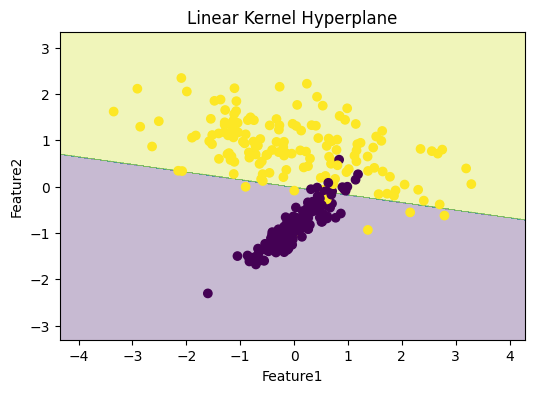

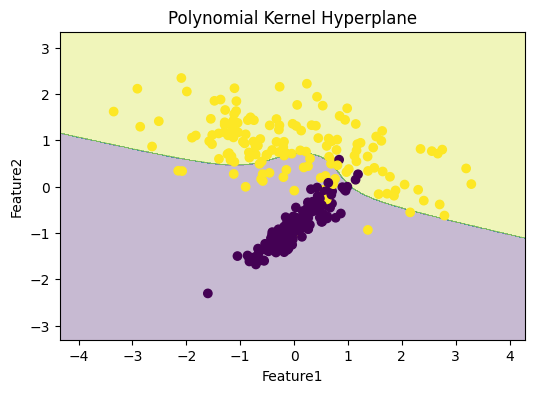

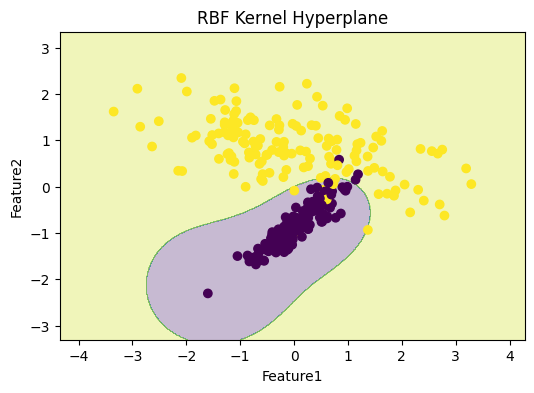

In [10]:
plot_decision_boundary(
    svm_linear,
    X_scaled,
    y,
    "Linear Kernel Hyperplane"
)

plot_decision_boundary(
    svm_poly,
    X_scaled,
    y,
    "Polynomial Kernel Hyperplane"
)

plot_decision_boundary(
    svm_rbf,
    X_scaled,
    y,
    "RBF Kernel Hyperplane"
)

In [ ]:
'''
*Final Outcome
Implemented SVM with multiple kernels
Compared kernel performance
Visualized hyperplanes
Understood nonlinear classification using kernel trick '''